# 👋 Welcome to QDW 2026

| | |
|---|---|
| 📍 **Workshop** | Quantum Device Design — QDW 2026 |
| 📓 **Notebook** | `01_welcome.ipynb` |
| ⏱️ **Time** | ~5 minutes |
| 🔗 **Prerequisite** | a running workshop env (Docker image or local `quantum-metal[full]>=0.7.2`) |


This is the warm-up. By the end you'll have rendered a real superconducting qubit on screen — proof that your environment is wired up correctly. The physics starts in [`02_first_chip_layout.ipynb`](./02_first_chip_layout.ipynb).


## 1. Import + render a transmon

Three lines to import, four to lay down a transmon qubit, one to look at it. If the picture appears below — your environment is working. We'll explain everything in the next notebook.


In [1]:
import qiskit_metal as qm
from qiskit_metal import designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design = designs.DesignPlanar()   # Let's start with a planar design
gui = qm.gui(design)              # Launch a web or desktop Metal gui

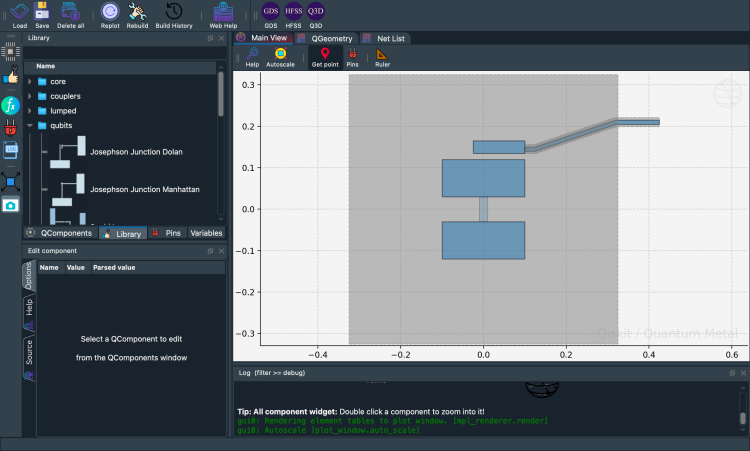

In [2]:
q1 = TransmonPocket(
    design, "Q1",
    options=dict(pad_width="200 um", pad_gap="60 um",
                 connection_pads=dict(a=dict(loc_W=+1, loc_H=+1))),
)
design.overwrite_enabled = True 
gui.rebuild()
gui.autoscale()
gui.screenshot()

🎉 If you see a small blue qubit pocket with two metal pads, a junction strip between them, and a coupling-pad nub at the upper-right — **you're good to go**.

The dimensions above (103 µm pads, 60 µm gap) match every notebook in this workshop — so the chip you just rendered is the *same* device you'll analyse with Palace in `03_transmon_and_resonator.ipynb`.


## 2. About the viewer that opened

Quantum Metal has two viewers, same Python API:

- 🖥️ **Qt `MetalGUI`** — desktop app with dockable side-panels. Needs PySide6 + a forwarded display.
- 🌐 **`MetalGUIHeadless`** — inline matplotlib in the Jupyter cell. The workshop Docker image's default (`QISKIT_METAL_HEADLESS=1` in `compose.yaml`).

The `qm.gui(design)` factory picked whichever fits your env automatically. Same `gui.rebuild()`, `gui.screenshot()`, `gui.edit_component()`, `gui.highlight_components()`, `gui.zoom_on_components()` in both.


In [3]:
print(f"You got: {type(gui).__name__}")
print(f"Quantum Metal: v{qm.__version__}")


You got: MetalGUI
Quantum Metal: v0.7.3


<details><summary>How to switch between Qt and headless modes</summary>

- **Want the Qt window?** Set up display forwarding (`docs/gui-forwarding.md`), unset `QISKIT_METAL_HEADLESS`, restart the kernel.
- **Want to force headless** (e.g. for a Colab or CI run)?
  ```python
  import os
  os.environ["QISKIT_METAL_HEADLESS"] = "1"
  # then restart the kernel
  ```

</details>


## 3. (Optional) what backends are available?

`qm.about()` reports which renderers + analysis backends are visible. The trailing `;` suppresses the noisy return-value print.


In [4]:
qm.about();


Qiskit Metal        0.7.3

Basic
____________________________________
 Python              3.12.13 (main, May 10 2026, 19:20:41) [Clang 22.1.3 ]
 Platform            Darwin arm64
 Installation path   /Users/zlatkominev/CODE_REPOS/quantum_hardware/qiskit-metal/src/qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.3.0

Rendering
____________________________________
 Matplotlib          3.10.9

GUI
____________________________________
 PySide6 version     6.11.1
 Qt version          6.11.1
 SIP version         Not installed

IBM Quantum Team


**Required for the workshop:**

- `quantum-metal >= 0.7.2`, `matplotlib`, `numpy`, `scipy`, `scqubits`
- (Qt mode only) PySide6 + a forwarded display

**Nice to have** — only needed by specific later sessions, skipped cleanly if missing: Palace, Ansys HFSS/Q3D/pyEPR, gmsh/ElmerFEM, SQDMetal.

If a *required* package is missing, flag a workshop helper. Common gotchas: [common-issues fold](#common-issues).


<a id="common-issues"></a>
<details><summary>Common issues — symptom → cause</summary>

| Symptom | Likely cause |
|---|---|
| `ModuleNotFoundError: PySide6` | Lite install — rebuild Docker or `pip install 'quantum-metal[gui]'`. |
| `qm.gui(design)` returned `MetalGUIHeadless` but you wanted Qt | No display forwarded. See [`docs/gui-forwarding.md`](../../../docs/gui-forwarding.md). |
| Palace SIGILLs on Apple Silicon | QEMU lacks AVX2. See [`docs/access.md`](../../../docs/access.md). |
| `qm.__version__` < 0.7.2 | `uv sync` (local) or rebuild Docker. |

</details>


## What's next

| | |
|---|---|
| 📐 [`02_first_chip_layout.ipynb`](./02_first_chip_layout.ipynb) | **Physics-first** walkthrough of what you just rendered (junction → transmon → CPW resonator → I/O) + Metal's multi-renderer architecture. |
| 🔬 [`03_transmon_and_resonator.ipynb`](./03_transmon_and_resonator.ipynb) | Charge dispersion, full Hamiltonian, EPR, Palace EM. Same chip. |
| 🔗 [`04_qubit_qubit_coupling.ipynb`](./04_qubit_qubit_coupling.ipynb) | Two qubits + tunable bus; cross-resonance gate setup. |
| 🧩 [`05_project.ipynb`](./05_project.ipynb) | Open-ended workshop project. |

⭐ **Quantum Metal — first stop:** [Docs](https://qiskit-community.github.io/qiskit-metal/) · [Tutorials index](https://qiskit-community.github.io/qiskit-metal/tut/index.html) · [Component Gallery](https://qiskit-community.github.io/qiskit-metal/qcomponents-gallery.html)

### Full resource list — videos, ecosystem, architecture, headless guide

- 🎥 [Video lectures](https://qiskit-community.github.io/qiskit-metal/videoseducation.html)
- 🧭 [Architecture overview](https://qiskit-community.github.io/qiskit-metal/architecture.html)
- 🌐 [Headless usage guide](https://qiskit-community.github.io/qiskit-metal/headless-usage.html)
- 🌍 [Ecosystem](https://qiskit-community.github.io/qiskit-metal/ecosystem.html) — SQuADDS, SQDMetal, ML-qubit-design, Qiskit-Metal-to-Litho, Palace integration.



## 💬 Stay connected — the Quantum Device Consortium

Workshops are starting points; the community is where the work continues. The single best place to find us — for questions, bugs, design help, or to share what you built — is:

### → [Quantum Device Consortium Discord]({{QDC_DISCORD_INVITE_URL}})

> ⚠️ **Workshop org TODO**: replace `{{QDC_DISCORD_INVITE_URL}}` with a fresh non-expiring Discord invite before publishing.

### More ways to engage — mailing list · GitHub · contribute · maintainers

- 🐛 **Bug reports / feature requests** → [`qiskit-community/qiskit-metal` issues](https://github.com/qiskit-community/qiskit-metal/issues).
- 📬 **QDW + Quantum Device Consortium news + future workshops** → contact `{{QDW_CONTACT_EMAIL}}` to be added to the mailing list. *(Workshop org: fill in.)*
- 🤝 **Contribute** — PRs welcome on `qiskit-metal`, `SQDMetal`, and the broader [ecosystem](https://qiskit-community.github.io/qiskit-metal/ecosystem.html). Easy starting points: tutorial typos, a new [QComponent](https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.31-Create-a-QComponent-Basic.html), a renderer fix.
- 🧑‍🔧 We're looking for maintainers. Quantum Metal is community-maintained and the surface area is growing. If you'd like to steward a piece, reach out on Discord or to the QDW organising team.

